In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.linalg import solve_banded
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

ЗАДАНИЕ 1

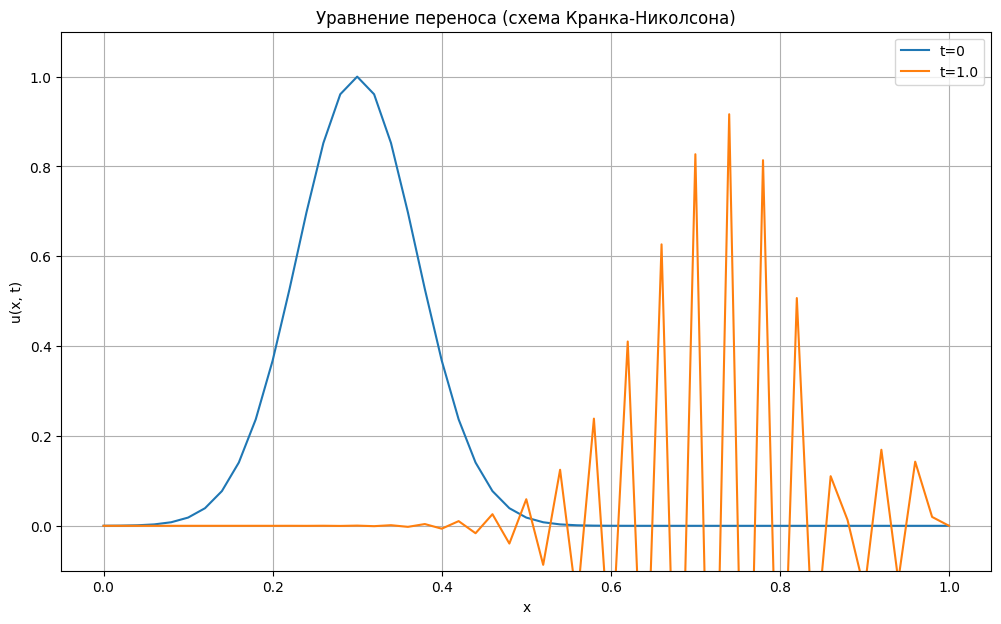

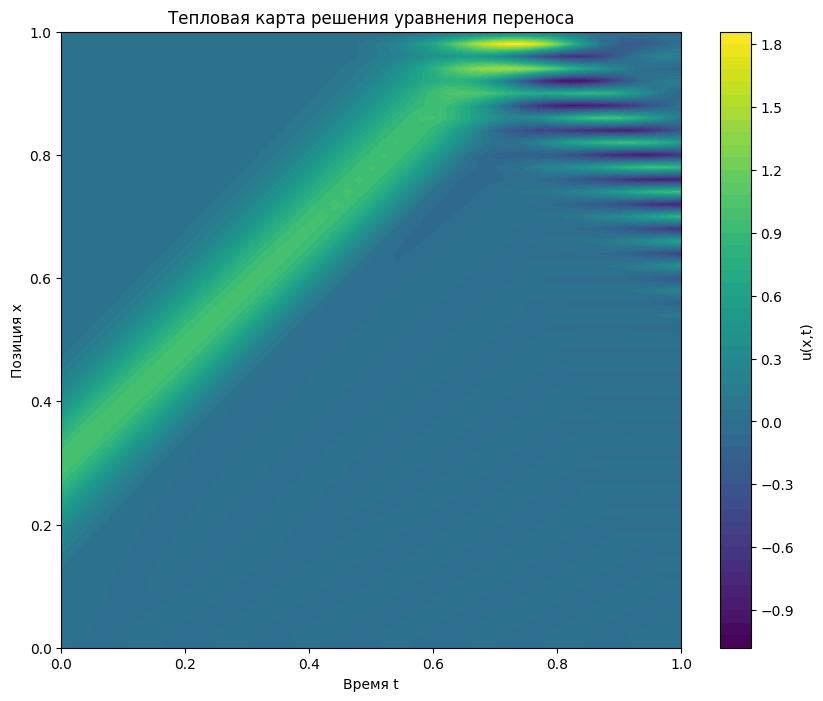

In [2]:
def sol_adv_cn(a, L, T, h, tau, phi0):
    Nx = int(L / h) + 1
    Nt = int(T / tau) + 1
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    C = a * tau / h
    u = np.zeros((Nt, Nx))
    u[0, :] = phi0(x)

    alpha = -C / 4
    beta = 1.0
    gamma = C / 4

    ab = np.zeros((3, Nx))
    ab[0, 1:] = gamma
    ab[1, :] = beta
    ab[2, :-1] = alpha

    for n in range(Nt - 1):
        u_curr = u[n, :].copy()
        rhs_expl = np.zeros(Nx)
        rhs_expl[1:-1] = - C/4 * (u_curr[2:] - u_curr[:-2])
        rhs_calc = u_curr + rhs_expl
        rhs_calc[0] = 0
        rhs_calc[-1] = 0

        ab_fixed = np.zeros((3, Nx))
        ab_fixed[0, 1:] = gamma
        ab_fixed[1, :] = beta
        ab_fixed[2, :-1] = alpha
        ab_fixed[1, 0] = 1.0
        ab_fixed[0, 1] = 0
        ab_fixed[2, 0] = 0
        ab_fixed[1, -1] = 1.0
        ab_fixed[2, -2] = 0
        ab_fixed[0,-1] = 0

        try:
            u[n+1, :] = solve_banded((1, 1), ab_fixed, rhs_calc)
        except np.linalg.LinAlgError:
            print(f"Ошибка LinAlg на шаге {n}.")
            return x, t, u

        u[n+1, 0] = 0
        u[n+1, -1] = 0

    return x, t, u

a_param = 1.0
L_param = 1.0
T_param = 1.0
h_param = 0.02
tau_param = 0.02
phi0_def = lambda x: np.exp(-100 * (x - 0.3)**2)

x_grid, t_grid, u_sol = sol_adv_cn(a_param, L_param, T_param, h_param, tau_param, phi0_def)

plt.figure(figsize=(12, 7))
plt.plot(x_grid, u_sol[0, :], label='t=0')
plt.plot(x_grid, u_sol[-1, :], label=f't={T_param}')
plt.title('Уравнение переноса (схема Кранка-Николсона)')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.grid(True)
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

plt.figure(figsize=(10, 8))
T_mesh, X_mesh = np.meshgrid(t_grid, x_grid)
plt.contourf(T_mesh, X_mesh, u_sol.T, 50, cmap=cm.viridis)
plt.colorbar(label='u(x,t)')
plt.xlabel('Время t')
plt.ylabel('Позиция x')
plt.title('Тепловая карта решения уравнения переноса')
plt.show()

ЗАДАНИЕ 2

Устойчивый случай: h=0.05, tau=0.00113, r=0.450
Неустойчивый случай: h=0.05, tau=0.00138, r=0.550
Предупреждение FTCS: r = 0.5500 > 0.5


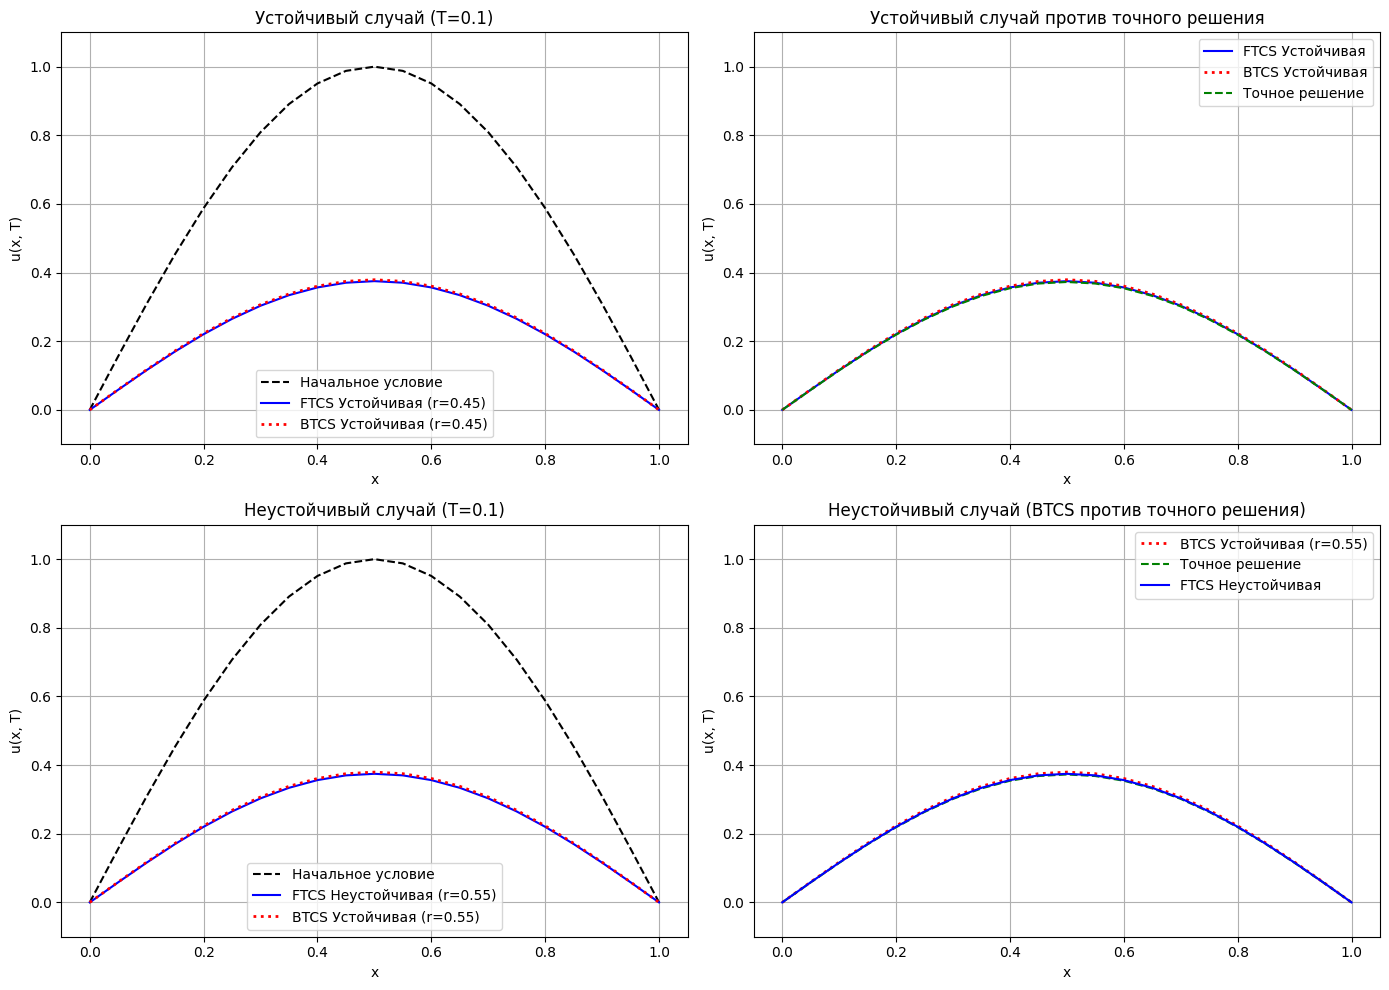

In [3]:
def sol_heat_ftcs(a2, L, T, h, tau, psi0, bc_l=0, bc_r=0):
    Nx = int(L / h) + 1
    Nt = int(T / tau) + 1
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    r = a2 * tau / h**2
    if r > 0.5:
        print(f"Предупреждение FTCS: r = {r:.4f} > 0.5")
    u = np.zeros((Nt, Nx))
    u[0, :] = psi0(x)
    for n in range(Nt - 1):
        u[n+1, 1:-1] = u[n, 1:-1] + r * (u[n, 2:] - 2*u[n, 1:-1] + u[n, :-2])
        u[n+1, 0] = bc_l
        u[n+1, -1] = bc_r
    return x, t, u

def sol_heat_btcs(a2, L, T, h, tau, psi0, bc_l=0, bc_r=0):
    Nx = int(L / h) + 1
    Nt = int(T / tau) + 1
    x = np.linspace(0, L, Nx)
    t = np.linspace(0, T, Nt)
    r = a2 * tau / h**2
    u = np.zeros((Nt, Nx))
    u[0, :] = psi0(x)

    alpha = -r
    beta = 1 + 2*r
    gamma = -r

    ab = np.zeros((3, Nx))
    ab[0, 1:] = gamma
    ab[1, :] = beta
    ab[2, :-1] = alpha
    ab[1, 0] = 1.0
    ab[0, 1] = 0
    ab[1, -1] = 1.0
    ab[2, -2] = 0

    for n in range(Nt - 1):
        rhs = u[n, :].copy()
        rhs[0] = bc_l
        rhs[-1] = bc_r
        try:
            u[n+1, :] = solve_banded((1, 1), ab, rhs)
        except np.linalg.LinAlgError:
            print(f"Ошибка LinAlg на шаге {n} (BTCS).")
            return x, t, u
    return x, t, u

a2 = 1.0
L = 1.0
T = 0.1
h = 0.05
psi0_def = lambda x: np.sin(np.pi * x / L)

tau_s = 0.5 * h**2 / a2 * 0.9
r_s = a2 * tau_s / h**2
print(f"Устойчивый случай: h={h}, tau={tau_s:.5f}, r={r_s:.3f}")
x_fs, t_fs, u_fs = sol_heat_ftcs(a2, L, T, h, tau_s, psi0_def)
x_bs, t_bs, u_bs = sol_heat_btcs(a2, L, T, h, tau_s, psi0_def)

tau_u = 0.5 * h**2 / a2 * 1.1
r_u = a2 * tau_u / h**2
print(f"Неустойчивый случай: h={h}, tau={tau_u:.5f}, r={r_u:.3f}")
x_fu, t_fu, u_fu = sol_heat_ftcs(a2, L, T, h, tau_u, psi0_def)
x_bu, t_bu, u_bu = sol_heat_btcs(a2, L, T, h, tau_u, psi0_def)

u_ex_s = np.exp(-a2 * (np.pi/L)**2 * T) * np.sin(np.pi * x_fs / L)
max_u_fu = np.max(np.abs(u_fu[-1, :]))

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(x_fs, u_fs[0, :], 'k--', label='Начальное условие')
plt.plot(x_fs, u_fs[-1, :], 'b-', label=f'FTCS Устойчивая (r={r_s:.2f})')
plt.plot(x_bs, u_bs[-1, :], 'r:', lw=2, label=f'BTCS Устойчивая (r={r_s:.2f})')
plt.title(f'Устойчивый случай (T={T})')
plt.xlabel('x'); plt.ylabel('u(x, T)'); plt.legend(); plt.grid(True); plt.ylim(-0.1, 1.1)

plt.subplot(2, 2, 2)
plt.plot(x_fs, u_fs[-1, :], 'b-', label=f'FTCS Устойчивая')
plt.plot(x_bs, u_bs[-1, :], 'r:', lw=2, label=f'BTCS Устойчивая')
plt.plot(x_fs, u_ex_s, 'g--', label='Точное решение')
plt.title('Устойчивый случай против точного решения')
plt.xlabel('x'); plt.ylabel('u(x, T)'); plt.legend(); plt.grid(True); plt.ylim(-0.1, 1.1)

plt.subplot(2, 2, 3)
plt.plot(x_fu, u_fu[0, :], 'k--', label='Начальное условие')
plt.plot(x_fu, u_fu[-1, :], 'b-', label=f'FTCS Неустойчивая (r={r_u:.2f})')
plt.plot(x_bu, u_bu[-1, :], 'r:', lw=2, label=f'BTCS Устойчивая (r={r_u:.2f})')
plt.title(f'Неустойчивый случай (T={T})')
plt.xlabel('x'); plt.ylabel('u(x, T)'); plt.legend(); plt.grid(True)
if max_u_fu > 10: plt.ylim(-1.5, 1.5)
else: plt.ylim(-0.1, 1.1)

plt.subplot(2, 2, 4)
plt.plot(x_bu, u_bu[-1, :], 'r:', lw=2, label=f'BTCS Устойчивая (r={r_u:.2f})')
u_ex_u = np.exp(-a2 * (np.pi/L)**2 * T) * np.sin(np.pi * x_bu / L)
plt.plot(x_bu, u_ex_u, 'g--', label='Точное решение')
if max_u_fu < 10:
    plt.plot(x_fu, u_fu[-1, :], 'b-', label=f'FTCS Неустойчивая')
plt.title('Неустойчивый случай (BTCS против точного решения)')
plt.xlabel('x'); plt.ylabel('u(x, T)'); plt.legend(); plt.grid(True); plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

ЗАДАНИЕ 3

Исследование сходимости...
ADI: h=0.100, tau=0.1000, Nx=11, Ny=11, Nt=2, Время=0.00с
h=0.1000, Макс. Ошибка=2.870e-02, L2 Ошибка=1.435e-02
ADI: h=0.050, tau=0.0500, Nx=21, Ny=21, Nt=3, Время=0.00с
h=0.0500, Макс. Ошибка=6.865e-03, L2 Ошибка=3.433e-03
ADI: h=0.025, tau=0.0250, Nx=41, Ny=41, Nt=5, Время=0.01с
h=0.0250, Макс. Ошибка=1.699e-03, L2 Ошибка=8.493e-04
ADI: h=0.013, tau=0.0125, Nx=81, Ny=81, Nt=9, Время=0.04с
h=0.0125, Макс. Ошибка=4.236e-04, L2 Ошибка=2.118e-04

Порядок (Макс): 2.026
Порядок (L2):  2.026


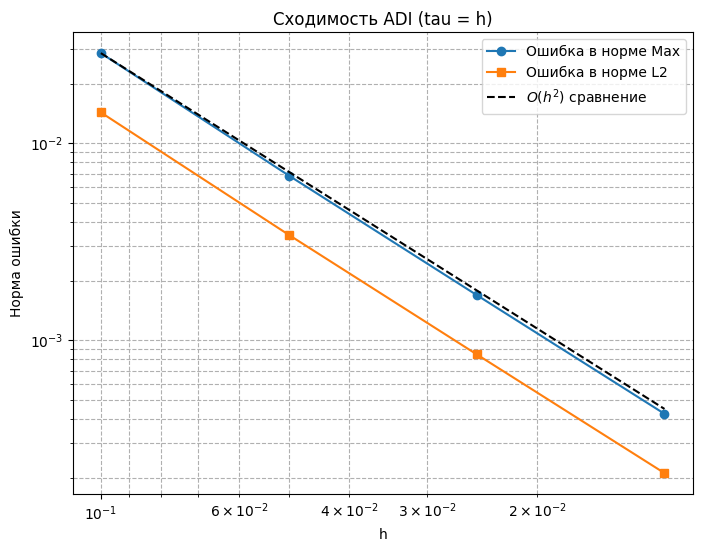

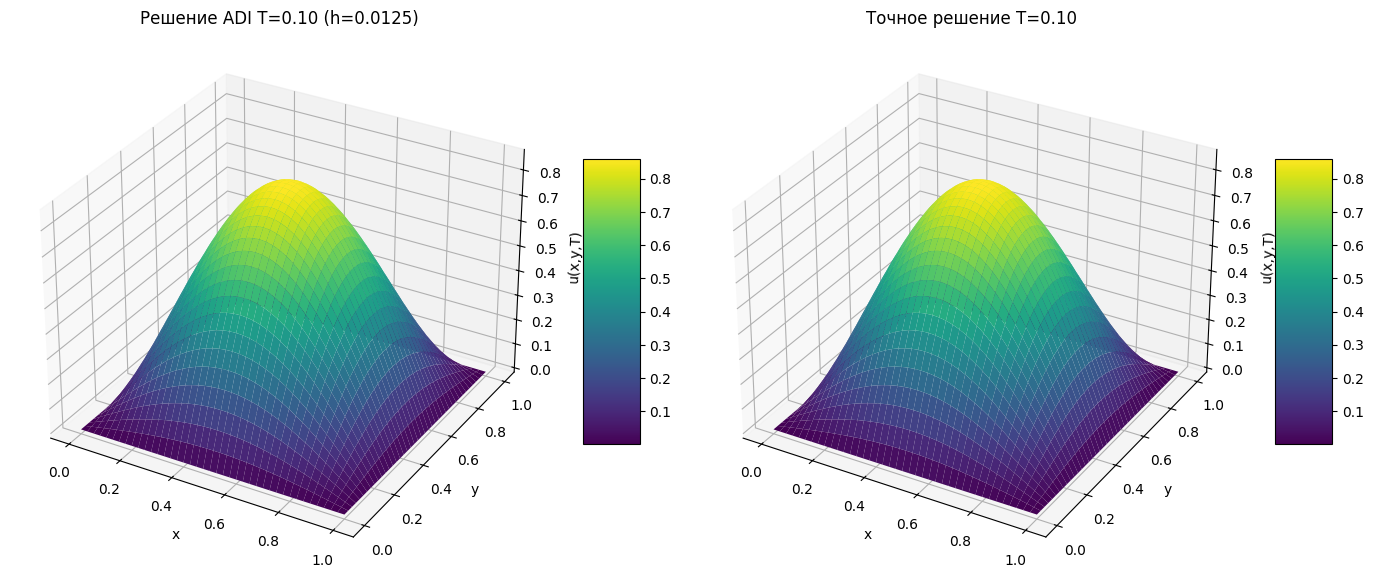

In [4]:
def sol_heat_2d_adi(Lx, Ly, T, h, tau, f_src, u_ex):
    Nx = int(Lx / h) + 1
    Ny = int(Ly / h) + 1
    Nt = int(T / tau) + 1
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    t = np.linspace(0, T, Nt)
    rx = tau / (2 * h**2)
    ry = tau / (2 * h**2)

    U = np.zeros((Nx, Ny))
    U_half = np.zeros((Nx, Ny))
    U_new = np.zeros((Nx, Ny))

    X, Y = np.meshgrid(x, y, indexing='ij')
    F = f_src(X, Y)
    F_term = (tau / 2) * F

    ab_x = np.zeros((3, Nx))
    ab_x[0, 1:] = -rx; ab_x[1, :] = 1 + 2*rx; ab_x[2, :-1] = -rx
    ab_x[1, 0] = 1.0; ab_x[0, 1] = 0; ab_x[1, -1] = 1.0; ab_x[2, -2] = 0

    ab_y = np.zeros((3, Ny))
    ab_y[0, 1:] = -ry; ab_y[1, :] = 1 + 2*ry; ab_y[2, :-1] = -ry
    ab_y[1, 0] = 1.0; ab_y[0, 1] = 0; ab_y[1, -1] = 1.0; ab_y[2, -2] = 0

    t_start = time.time()
    for n in range(Nt - 1):
        RHS1 = np.zeros_like(U)
        for k in range(1, Ny - 1):
             RHS1[1:-1, k] = U[1:-1, k] + ry * (U[1:-1, k+1] - 2*U[1:-1, k] + U[1:-1, k-1])
        RHS1 += F_term
        for k in range(Ny):
            rhs_k = RHS1[:, k].copy()
            rhs_k[0] = 0; rhs_k[-1] = 0
            U_half[:, k] = solve_banded((1, 1), ab_x, rhs_k)

        RHS2 = np.zeros_like(U_half)
        for j in range(1, Nx - 1):
             RHS2[j, 1:-1] = U_half[j, 1:-1] + rx * (U_half[j+1, 1:-1] - 2*U_half[j, 1:-1] + U_half[j-1, 1:-1])
        RHS2 += F_term
        for j in range(Nx):
            rhs_j = RHS2[j, :].copy()
            rhs_j[0] = 0; rhs_j[-1] = 0
            U_new[j, :] = solve_banded((1, 1), ab_y, rhs_j)
        U = U_new.copy()
    t_end = time.time()
    print(f"ADI: h={h:.3f}, tau={tau:.4f}, Nx={Nx}, Ny={Ny}, Nt={Nt}, Время={t_end - t_start:.2f}с")
    return x, y, U

Lx = 1.0
Ly = 1.0
Tf = 0.1
f_src_def = lambda x, y: 2 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
u_ex_def = lambda x, y, t: (1 - np.exp(-2 * np.pi**2 * t)) * np.sin(np.pi * x) * np.sin(np.pi * y)

hs = [0.1, 0.05, 0.025, 0.0125]
err_max = []
err_l2 = []

print("Исследование сходимости...")
for h_val in hs:
    tau_val = h_val
    x_num, y_num, u_num = sol_heat_2d_adi(Lx, Ly, Tf, h_val, tau_val, f_src_def, u_ex_def)
    X_num, Y_num = np.meshgrid(x_num, y_num, indexing='ij')
    U_ex = u_ex_def(X_num, Y_num, Tf)
    error_mat = u_num - U_ex
    error_max = np.max(np.abs(error_mat))
    error_l2 = np.sqrt(np.sum(error_mat**2) * h_val * h_val)
    err_max.append(error_max)
    err_l2.append(error_l2)
    print(f"h={h_val:.4f}, Макс. Ошибка={error_max:.3e}, L2 Ошибка={error_l2:.3e}")

hs_arr = np.array(hs)
err_max_arr = np.array(err_max)
err_l2_arr = np.array(err_l2)
log_h = np.log(hs_arr)
log_err_max = np.log(err_max_arr)
log_err_l2 = np.log(err_l2_arr)
order_max, _ = np.polyfit(log_h, log_err_max, 1)
order_l2, _ = np.polyfit(log_h, log_err_l2, 1)
print(f"\nПорядок (Макс): {order_max:.3f}")
print(f"Порядок (L2):  {order_l2:.3f}")

plt.figure(figsize=(8, 6))
plt.loglog(hs_arr, err_max_arr, 'o-', label='Ошибка в норме Max')
plt.loglog(hs_arr, err_l2_arr, 's-', label='Ошибка в норме L2')
plt.loglog(hs_arr, (err_max_arr[0] / (hs_arr[0]**2)) * hs_arr**2, 'k--', label='$O(h^2)$ сравнение')
plt.xlabel('h'); plt.ylabel('Норма ошибки')
plt.title('Сходимость ADI (tau = h)')
plt.grid(True, which="both", ls="--"); plt.legend()
plt.gca().invert_xaxis()
plt.show()

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
X_num, Y_num = np.meshgrid(x_num, y_num, indexing='ij')
surf1 = ax1.plot_surface(X_num, Y_num, u_num, cmap=cm.viridis)
ax1.set_title(f'Решение ADI T={Tf:.2f} (h={h_val:.4f})')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('u(x,y,T)')
fig.colorbar(surf1, shrink=0.5, aspect=5)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
U_ex_final = u_ex_def(X_num, Y_num, Tf)
surf2 = ax2.plot_surface(X_num, Y_num, U_ex_final, cmap=cm.viridis)
ax2.set_title(f'Точное решение T={Tf:.2f}')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('u(x,y,T)')
fig.colorbar(surf2, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

ЗАДАНИЕ 4

Запуск нелинейной релаксации Nx=51, Ny=26...
Итерация: 1000, Макс. Изменение (u^2): 1.570e-04
Итерация: 2000, Макс. Изменение (u^2): 1.112e-06
Сконвергировалось за 2488 итераций. Финальная разница = 9.969e-08
Время решения: 7.10с


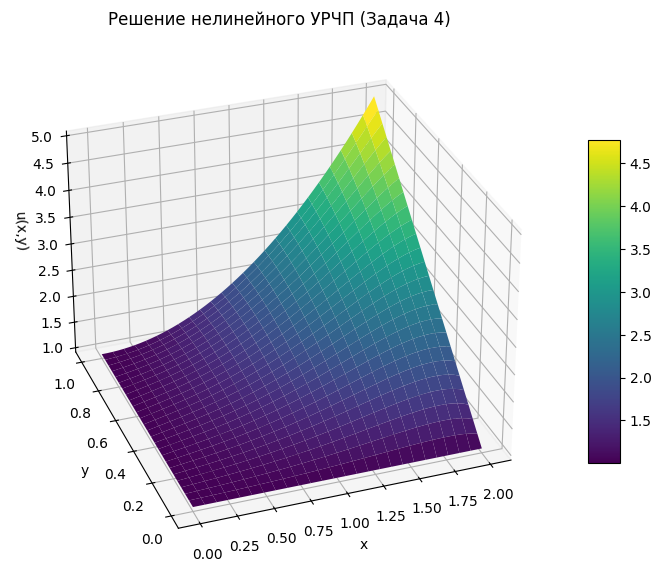

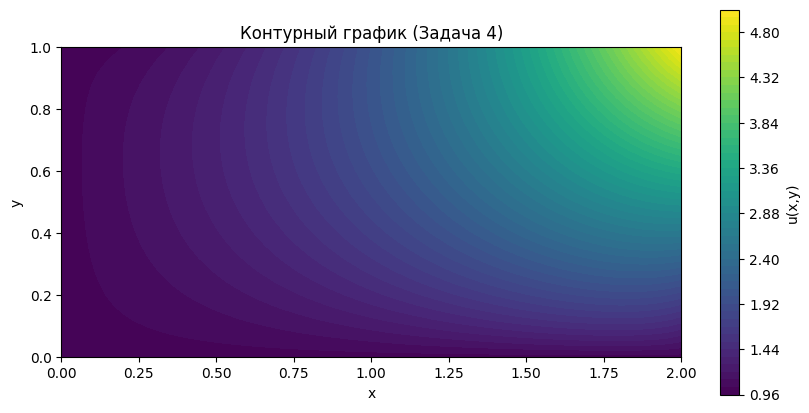

In [5]:
def sol_nonlin_laplace(X, Y, Nx, Ny, bc, tol=1e-7, max_iter=20000):
    hx = X / (Nx - 1)
    hy = Y / (Ny - 1)
    x = np.linspace(0, X, Nx)
    y = np.linspace(0, Y, Ny)

    U = np.ones((Nx, Ny))

    U[0, :] = bc(0.0, y)
    U[-1, :] = bc(X, y)
    U[:, 0] = bc(x, 0.0)
    U[:, -1] = bc(x, Y)


    hx2 = hx**2
    hy2 = hy**2
    denom = 2.0 * (1.0/hx2 + 1.0/hy2)

    iter_n = 0
    diff = tol + 1
    t_start = time.time()
    print(f"Запуск нелинейной релаксации Nx={Nx}, Ny={Ny}...")

    while diff > tol and iter_n < max_iter:
        U_old_sq = U**2
        U_read = U.copy()

        for j in range(1, Nx - 1):
            for k in range(1, Ny - 1):
                v_neigh = (U_read[j+1, k]**2 + U_read[j-1, k]**2) / hx2 + \
                          (U_read[j, k+1]**2 + U_read[j, k-1]**2) / hy2
                v_jk = v_neigh / denom
                if v_jk < 0: v_jk = 0
                U[j, k] = np.sqrt(v_jk)

        diff = np.max(np.abs(U**2 - U_old_sq))
        iter_n += 1
        if iter_n % 1000 == 0:
            print(f"Итерация: {iter_n}, Макс. Изменение (u^2): {diff:.3e}")

    t_end = time.time()
    if iter_n == max_iter:
        print(f"Предупреждение: Достигнуто макс. число итераций ({max_iter}). Разница = {diff:.3e}")
    else:
        print(f"Сконвергировалось за {iter_n} итераций. Финальная разница = {diff:.3e}")
    print(f"Время решения: {t_end - t_start:.2f}с")
    return x, y, U

Xp = 2.0
Yp = 1.0
Nx4 = 51
Ny4 = 26

def bc_def(x_in, y_in):
    x_is_scalar = np.isscalar(x_in)
    y_is_scalar = np.isscalar(y_in)

    if x_is_scalar and not y_is_scalar:
        x_val = float(x_in)
        y_arr = np.asarray(y_in)
        u = np.ones_like(y_arr, dtype=float)

        if np.isclose(x_val, 0.0):
            u[:] = 1.0
        elif np.isclose(x_val, Xp):
            u[:] = 1.0 + Xp**2 * y_arr / Yp
        else:
            u[np.isclose(y_arr, 0.0)] = 1.0
            u[np.isclose(y_arr, Yp)] = 1.0 + x_val**2
        return u

    elif not x_is_scalar and y_is_scalar:
        x_arr = np.asarray(x_in)
        y_val = float(y_in)
        u = np.ones_like(x_arr, dtype=float)

        if np.isclose(y_val, 0.0):
            u[:] = 1.0
        elif np.isclose(y_val, Yp):
            u[:] = 1.0 + x_arr**2
        else:
             u[np.isclose(x_arr, 0.0)] = 1.0
             u[np.isclose(x_arr, Xp)] = 1.0 + Xp**2 * y_val / Yp
        return u

    elif x_is_scalar and y_is_scalar:
        x_val = float(x_in)
        y_val = float(y_in)
        u = 1.0

        if np.isclose(y_val, 0.0): u = 1.0
        if np.isclose(x_val, 0.0): u = 1.0
        if np.isclose(y_val, Yp): u = 1.0 + x_val**2
        if np.isclose(x_val, Xp): u = 1.0 + Xp**2 * y_val / Yp
        return u
    else:
        raise ValueError("Функция bc_def ожидает как минимум один скалярный вход от решателя")


x_nl, y_nl, u_nl = sol_nonlin_laplace(Xp, Yp, Nx4, Ny4, bc_def)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(1, 1, 1, projection='3d')
X_nl_grid, Y_nl_grid = np.meshgrid(x_nl, y_nl, indexing='ij')
surf = ax.plot_surface(X_nl_grid, Y_nl_grid, u_nl, cmap=cm.viridis)
ax.set_title('Решение нелинейного УРЧП (Задача 4)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u(x,y)')
ax.view_init(elev=30, azim=-110)
fig.colorbar(surf, shrink=0.6, aspect=10)
plt.show()

plt.figure(figsize=(10, 5))
contour = plt.contourf(x_nl, y_nl, u_nl.T, 50, cmap=cm.viridis)
plt.colorbar(contour, label='u(x,y)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Контурный график (Задача 4)')
plt.axis('image')
plt.show()